# NB2 — Autoencoder Training
## Jet Engine PHM — 1D-CNN Autoencoder for Anomaly Detection

**Inputs required:**
- `processed_data/X_nominal.npy`
- `processed_data/sensor_cols.pkl`
- `checkpoints/global_scaler.pkl`

**Outputs:**
- `checkpoints/autoencoder.pt` — trained AE weights
- `processed_data/X_recon_nominal.npy` — reconstructions of nominal windows
- `plots/nb2_ae_training_curve.png`, `plots/nb2_ae_recon_error.png`, `plots/nb2_ae_sensor_comparison.png`

## 0. Setup & Load Data from NB1

In [1]:
import sys, os, pickle, warnings, logging
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')

import numpy as np
import matplotlib.pyplot as plt
import torch

sys.path.insert(0, '..')
from models import ConvAutoencoder, AETrainer, DEVICE

PROC_DIR = '../processed_data'
CKPT_DIR = '../checkpoints'
PLOT_DIR = '../plots'

print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

2026-03-26 13:59:10,646 [INFO] GPU: NVIDIA RTX 4500 Ada Generation


Device : cuda
GPU    : NVIDIA RTX 4500 Ada Generation
VRAM   : 25.8 GB


In [2]:
# ── Load NB1 outputs ──────────────────────────────────────────────────────────
X_nominal = np.load(f'{PROC_DIR}/X_nominal.npy')
with open(f'{PROC_DIR}/sensor_cols.pkl', 'rb') as f:
    sensor_cols = pickle.load(f)
with open(f'{CKPT_DIR}/global_scaler.pkl', 'rb') as f:
    global_scaler = pickle.load(f)

print(f'X_nominal shape  : {X_nominal.shape}   dtype={X_nominal.dtype}')
print(f'Sensors          : {sensor_cols}')
print(f'Scaled range     : {X_nominal.min():.4f} → {X_nominal.max():.4f}')

2026-03-26 13:59:33,961 [INFO] NumExpr defaulting to 12 threads.


X_nominal shape  : (120506, 50, 14)   dtype=float32
Sensors          : ['T24', 'T30', 'T48', 'T50', 'P15', 'P2', 'P21', 'P24', 'Ps30', 'P40', 'P50', 'Nf', 'Nc', 'Wf']
Scaled range     : -0.0107 → 1.0079


## 1. Configuration

In [3]:
WINDOW_SIZE = X_nominal.shape[1]  # auto-detect from data (50)
N_SENSORS   = X_nominal.shape[2]  # auto-detect (14)

# ── Autoencoder hyperparameters ───────────────────────────────────────────────
AE_BASE_CH   = 32
AE_LATENT    = 64
AE_EPOCHS    = 120    # increase if GPU is available
BATCH_SIZE   = 512    # 512 fits comfortably on RTX 4500 (24 GB VRAM)
LR           = 1e-3
PATIENCE     = 20

print(f'Window size : {WINDOW_SIZE}  |  N sensors : {N_SENSORS}')
print(f'AE base_ch  : {AE_BASE_CH}  |  latent dim : {AE_LATENT}')
print(f'Epochs      : {AE_EPOCHS}   |  batch size : {BATCH_SIZE}')

Window size : 50  |  N sensors : 14
AE base_ch  : 32  |  latent dim : 64
Epochs      : 120   |  batch size : 512


## 2. Build & Train Autoencoder

In [4]:
ae_model = ConvAutoencoder(
    n_sensors   = N_SENSORS,
    window_size = WINDOW_SIZE,
    base_ch     = AE_BASE_CH,
    latent_dim  = AE_LATENT,
)
n_params = sum(p.numel() for p in ae_model.parameters())
print(f'AE total parameters: {n_params:,}')

ae_trainer = AETrainer(ae_model, lr=LR, device=DEVICE)

print(f'Training on {len(X_nominal):,} nominal windows …')
val_losses = ae_trainer.fit(
    X_nominal,
    epochs     = AE_EPOCHS,
    batch_size = BATCH_SIZE,
    val_split  = 0.10,
    patience   = PATIENCE,
)

# Save checkpoint
torch.save(ae_model.state_dict(), f'{CKPT_DIR}/autoencoder.pt')
print(f'\n✓ Autoencoder saved → {CKPT_DIR}/autoencoder.pt')

2026-03-26 14:00:18,080 [INFO] AE Bottleneck: 1792 -> 64 -> 1792


AE total parameters: 494,094
Training on 120,506 nominal windows …


2026-03-26 14:00:39,780 [INFO] AE Epoch  10/120 | train=0.000453 | val=0.000340
2026-03-26 14:00:57,745 [INFO] AE Epoch  20/120 | train=0.000259 | val=0.000185
2026-03-26 14:01:15,297 [INFO] AE Epoch  30/120 | train=0.000178 | val=0.000173
2026-03-26 14:01:32,981 [INFO] AE Epoch  40/120 | train=0.000117 | val=0.000244
2026-03-26 14:01:50,647 [INFO] AE Epoch  50/120 | train=0.000086 | val=0.000180
2026-03-26 14:01:59,380 [INFO] Early stop at epoch 55



✓ Autoencoder saved → ../checkpoints/autoencoder.pt


## 3. Training Curve

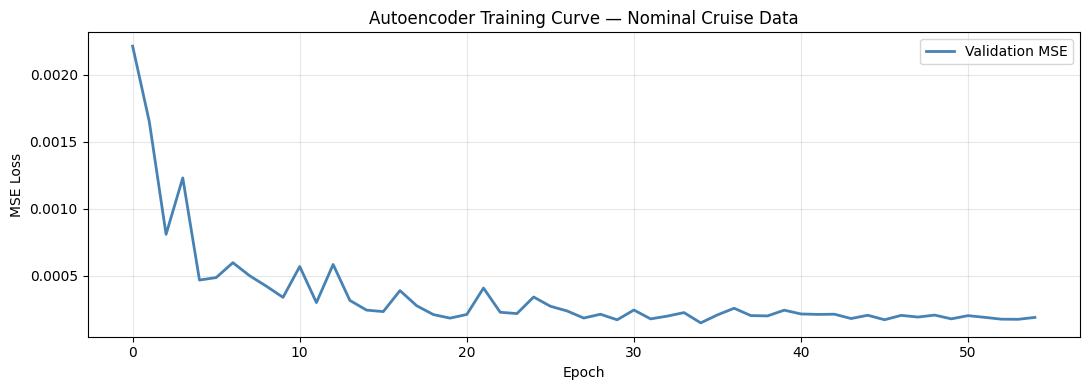

Best validation MSE : 0.000150


In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(val_losses, lw=2, color='steelblue', label='Validation MSE')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('Autoencoder Training Curve — Nominal Cruise Data')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/nb2_ae_training_curve.png', dpi=120)
plt.show()
print(f'Best validation MSE : {min(val_losses):.6f}')

## 4. Reconstruction Quality on Nominal Samples

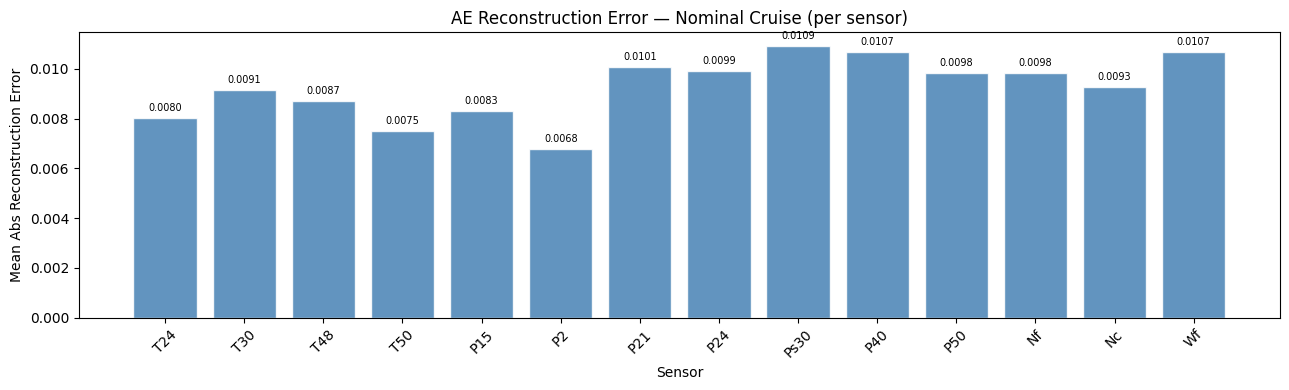

Overall mean MAE : 0.009259


In [6]:
# Reconstruct first 500 nominal windows
N_EVAL = min(500, len(X_nominal))
X_recon_nom = ae_trainer.reconstruct(X_nominal[:N_EVAL])
mae_per_sensor = np.abs(X_nominal[:N_EVAL] - X_recon_nom).mean(axis=(0, 1))

fig, ax = plt.subplots(figsize=(13, 4))
bars = ax.bar(sensor_cols, mae_per_sensor, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel('Sensor'); ax.set_ylabel('Mean Abs Reconstruction Error')
ax.set_title('AE Reconstruction Error — Nominal Cruise (per sensor)')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, mae_per_sensor):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/nb2_ae_recon_error.png', dpi=120)
plt.show()
print(f'Overall mean MAE : {mae_per_sensor.mean():.6f}')

## 5. Sensor-Level Overlay: Nominal vs Reconstruction

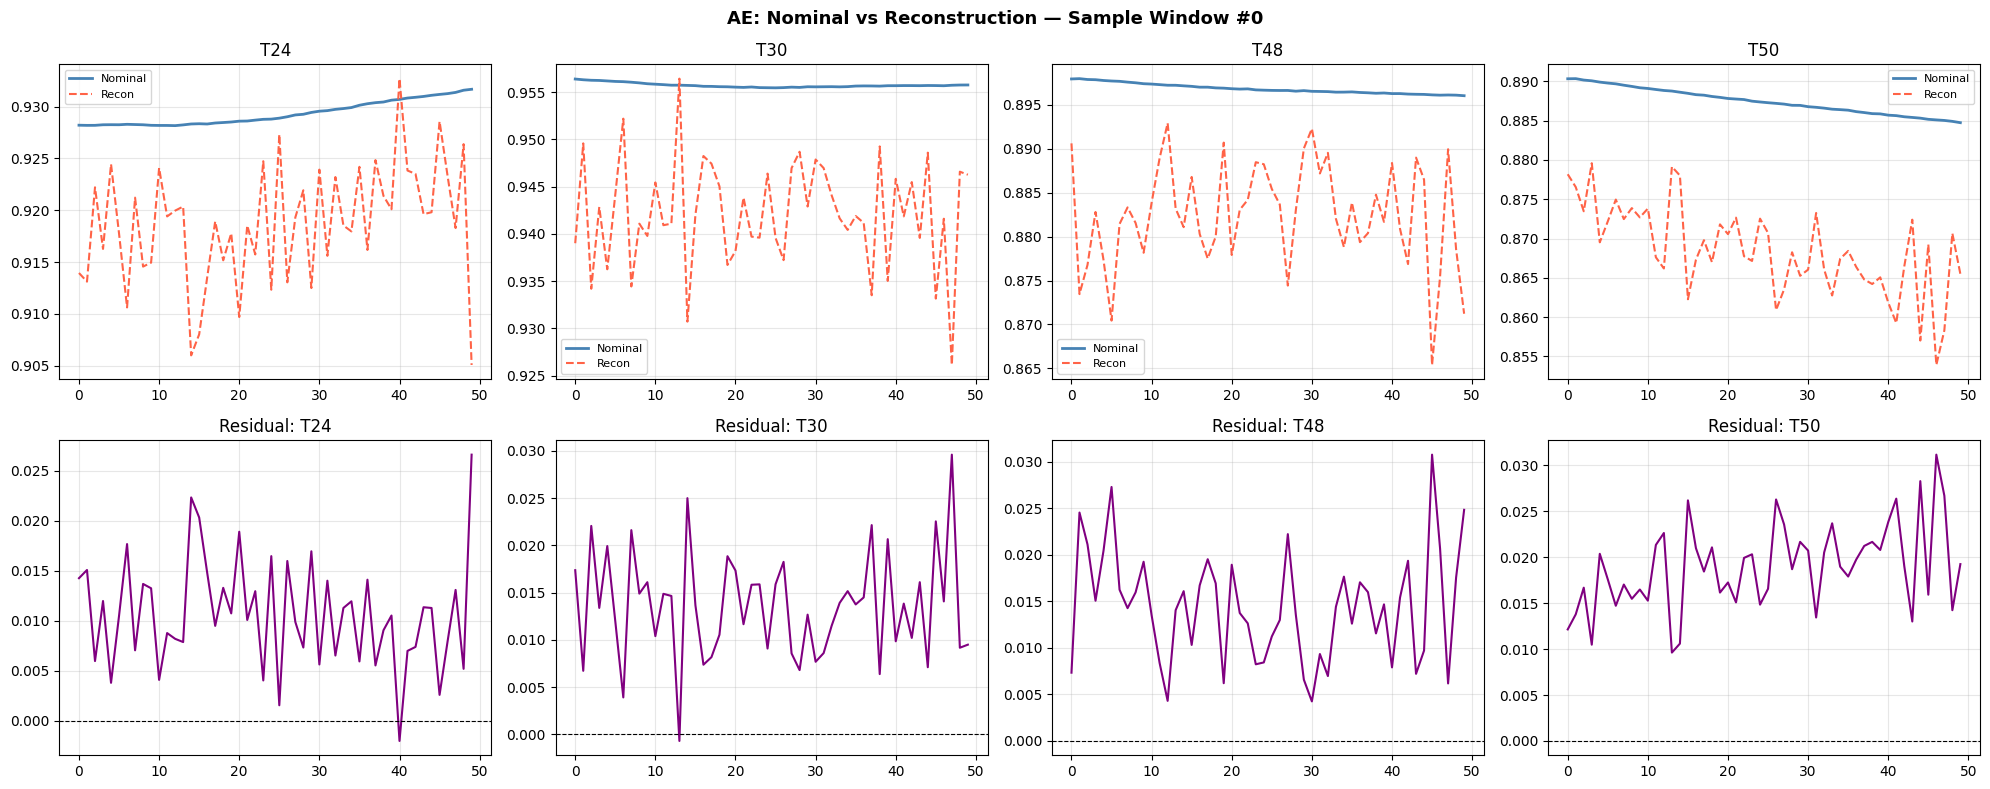

In [7]:
n_show = 4   # show first 4 sensors
fig, axes = plt.subplots(2, n_show, figsize=(20, 8))
fig.suptitle('AE: Nominal vs Reconstruction — Sample Window #0', fontsize=13, fontweight='bold')

for col, s in enumerate(range(n_show)):
    t_ = np.arange(WINDOW_SIZE)
    # Top: overlay
    axes[0, col].plot(t_, X_nominal[0, :, s], lw=2, label='Nominal', color='steelblue')
    axes[0, col].plot(t_, X_recon_nom[0, :, s], lw=1.5, ls='--', label='Recon', color='tomato')
    axes[0, col].set_title(sensor_cols[s]); axes[0, col].legend(fontsize=8); axes[0, col].grid(alpha=0.3)
    # Bottom: residual
    res = X_nominal[0, :, s] - X_recon_nom[0, :, s]
    axes[1, col].plot(t_, res, lw=1.5, color='purple')
    axes[1, col].axhline(0, color='black', lw=0.8, ls='--')
    axes[1, col].set_title(f'Residual: {sensor_cols[s]}')
    axes[1, col].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/nb2_ae_sensor_comparison.png', dpi=120)
plt.show()

## 6. Anomaly Score Distribution (Nominal Baseline)

Establish the reconstruction error distribution on nominal data —
this will be used later to set the anomaly detection threshold.

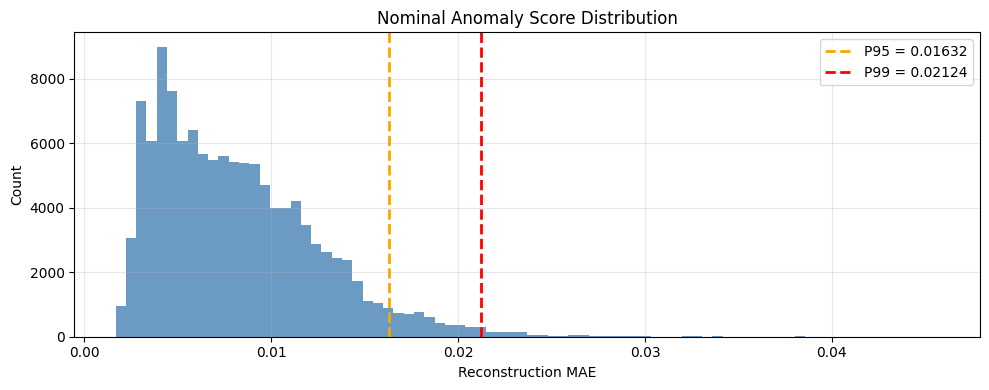

P95 threshold (5% FPR) : 0.01632
P99 threshold (1% FPR) : 0.02124


In [8]:
from models import ConvAutoencoder
import torch

# Compute per-window MAE for all nominal windows
RECON_BATCH = 512
re_scores = []
for i in range(0, len(X_nominal), RECON_BATCH):
    chunk = X_nominal[i:i+RECON_BATCH]
    recon = ae_trainer.reconstruct(chunk)
    re_scores.append(np.abs(chunk - recon).mean(axis=(1, 2)))
re_scores = np.concatenate(re_scores)

# Percentile-based threshold
RE_THRESH_95 = float(np.percentile(re_scores, 95))
RE_THRESH_99 = float(np.percentile(re_scores, 99))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(re_scores, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(RE_THRESH_95, color='orange', lw=2, ls='--', label=f'P95 = {RE_THRESH_95:.5f}')
ax.axvline(RE_THRESH_99, color='red', lw=2, ls='--', label=f'P99 = {RE_THRESH_99:.5f}')
ax.set_xlabel('Reconstruction MAE'); ax.set_ylabel('Count')
ax.set_title('Nominal Anomaly Score Distribution')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/nb2_anomaly_score_dist.png', dpi=120)
plt.show()
print(f'P95 threshold (5% FPR) : {RE_THRESH_95:.5f}')
print(f'P99 threshold (1% FPR) : {RE_THRESH_99:.5f}')

## 7. Save Reconstructions of Nominal Windows

In [9]:
print('Reconstructing all nominal windows …')
X_recon_nominal = np.zeros_like(X_nominal)
for i in range(0, len(X_nominal), RECON_BATCH):
    X_recon_nominal[i:i+RECON_BATCH] = ae_trainer.reconstruct(X_nominal[i:i+RECON_BATCH])

np.save(f'{PROC_DIR}/X_recon_nominal.npy', X_recon_nominal)
import json
thresholds = {'RE_THRESH_95': RE_THRESH_95, 'RE_THRESH_99': RE_THRESH_99}
with open(f'{CKPT_DIR}/ae_thresholds.json', 'w') as f:
    json.dump(thresholds, f, indent=2)

print(f'Saved X_recon_nominal    → {PROC_DIR}/X_recon_nominal.npy')
print(f'Saved ae_thresholds.json → {CKPT_DIR}/ae_thresholds.json')
print('\n✓ NB2 complete — Proceed to NB3_Clustering.ipynb')

Reconstructing all nominal windows …
Saved X_recon_nominal    → ../processed_data/X_recon_nominal.npy
Saved ae_thresholds.json → ../checkpoints/ae_thresholds.json

✓ NB2 complete — Proceed to NB3_Clustering.ipynb


## ↻ Reload checkpoint (run if kernel restarted)
Skip this cell if you just finished training.

In [10]:
# ── RELOAD BLOCK — run only if kernel was restarted ──────────────────────────
import sys, os, pickle, json
import numpy as np, torch
sys.path.insert(0, '..')
from models import ConvAutoencoder, AETrainer, DEVICE

PROC_DIR = '../processed_data'
CKPT_DIR = '../checkpoints'

X_nominal = np.load(f'{PROC_DIR}/X_nominal.npy')
with open(f'{PROC_DIR}/sensor_cols.pkl', 'rb') as f:
    sensor_cols = pickle.load(f)

ae_model = ConvAutoencoder(
    n_sensors   = X_nominal.shape[2],
    window_size = X_nominal.shape[1],
    base_ch     = 32, latent_dim = 64,
).to(DEVICE)
ae_model.load_state_dict(torch.load(f'{CKPT_DIR}/autoencoder.pt', map_location=DEVICE, weights_only=True))
ae_model.eval()
ae_trainer = AETrainer(ae_model, device=DEVICE)
print(f'✓ AE reloaded from {CKPT_DIR}/autoencoder.pt')

2026-03-26 14:08:17,920 [INFO] AE Bottleneck: 1792 -> 64 -> 1792


✓ AE reloaded from ../checkpoints/autoencoder.pt
